# FAD1 Visium–Xenium Benchmark

This benchmark uses the FAD1 Visium-Xenium serial sections from [Zenodo](https://zenodo.org/records/10520022) and the official Paper27/S3 27-class mapping/mask truth, which is distinct from the 55 µm registration proxy truth. Because Spotiphy did not release its final single-cell reference or complete preprocessing workflow, we reconstructed a 111,490-cell reference from public Allen mouse-brain and immune-enriched scRNA-seq components. Results are compared on 2,534 held-out spots supported by all three methods; here, TESLA denotes image-aware interpolation followed by the same frozen GA/TACCO and RNA-to-cell correction.

## Results

The table reports the median of each per-spot metric on the common held-out support. Arrows indicate whether higher or lower values are better.

In [1]:
%matplotlib inline

import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


INPUT = os.path.join(
    "..",
    "..",
    "results",
    "spotify_fad1_paper_repro",
    "tesla",
    "paper27_comparable_v1_verified",
    "metrics",
    "per_spot_metrics.csv",
)

METHODS = ["REVISE", "Spotiphy", "TESLA"]
EXPECTED_COMMON_HELD_OUT_SPOTS = 2_534
METRICS = [
    "pearson_correlation",
    "absolute_error_l1",
    "square_error_sum",
    "cosine_similarity",
    "fraction_cells_correctly_mapped",
    "jensen_shannon_distance",
]
METRIC_LABELS = {
    "pearson_correlation": "Correlation ↑",
    "absolute_error_l1": "L1 absolute error ↓",
    "square_error_sum": "Squared error sum ↓",
    "cosine_similarity": "Cosine similarity ↑",
    "fraction_cells_correctly_mapped": "Correctly mapped fraction ↑",
    "jensen_shannon_distance": "Jensen-Shannon distance ↓",
}

metrics = pd.read_csv(INPUT)
required_columns = {"method", "spot_id", "split", "tesla_supported", *METRICS}
missing = required_columns.difference(metrics.columns)
if missing:
    raise ValueError(f"Missing columns: {sorted(missing)}")
if set(metrics["method"]) != set(METHODS):
    raise ValueError(f"Unexpected methods: {sorted(metrics['method'].unique())}")
if metrics.duplicated(["method", "spot_id"]).any():
    raise ValueError("Duplicate method/spot_id rows were found")

plot_data = metrics.loc[
    metrics["split"].eq("held_out") & metrics["tesla_supported"],
    ["method", "spot_id", *METRICS],
].copy()
plot_data["method"] = pd.Categorical(
    plot_data["method"], categories=METHODS, ordered=True
)
plot_data = plot_data.sort_values(["method", "spot_id"])

counts = plot_data.groupby("method", observed=True).size().reindex(METHODS)
if not counts.eq(EXPECTED_COMMON_HELD_OUT_SPOTS).all():
    raise ValueError(f"Unexpected spot counts: {counts.to_dict()}")
spot_axes = [
    pd.Index(
        plot_data.loc[plot_data["method"].eq(method), "spot_id"]
        .sort_values()
        .to_numpy(),
        name="spot_id",
    )
    for method in METHODS
]
if not all(axis.equals(spot_axes[0]) for axis in spot_axes[1:]):
    raise ValueError("Methods use different held-out spot axes")
if not np.isfinite(plot_data[METRICS].to_numpy(dtype=float)).all():
    raise ValueError("One or more scored metrics contain NaN or Inf")

summary = (
    plot_data.groupby("method", observed=True)[METRICS]
    .median()
    .reindex(METHODS)
    .rename(columns=METRIC_LABELS)
)
summary.insert(0, "Spots", counts.astype(int))
summary.index.name = "Method"
summary.round(6)

,Spots,Correlation ↑,L1 absolute error ↓,Squared error sum ↓,Cosine similarity ↑,Correctly mapped fraction ↑,Jensen-Shannon distance ↓
Method,,,,,,,
REVISE,2534,0.653071,0.994084,0.162852,0.702272,0.502958,0.477321
Spotiphy,2534,0.599778,1.065934,0.168929,0.663478,0.467033,0.499755
TESLA,2534,0.618041,1.070857,0.190208,0.666948,0.464572,0.507860


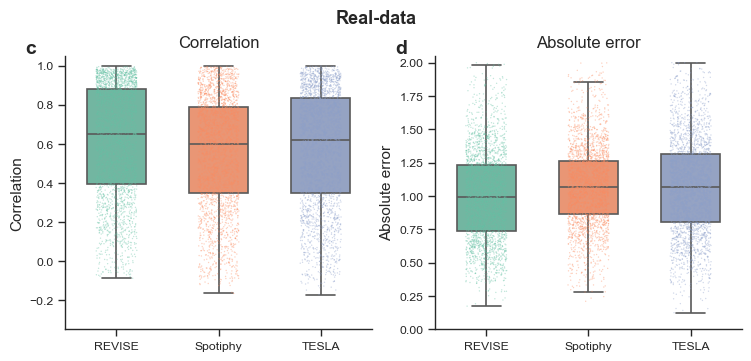

In [2]:
COLORS = {
    "REVISE": "#66C2A5",
    "Spotiphy": "#FC8D62",
    "TESLA": "#8DA0CB",
}
PANELS = [
    {
        "metric": "pearson_correlation",
        "title": "Correlation",
        "ylabel": "Correlation",
        "letter": "c",
        "ylim": (-0.35, 1.05),
    },
    {
        "metric": "absolute_error_l1",
        "title": "Absolute error",
        "ylabel": "Absolute error",
        "letter": "d",
        "ylim": (0, 2.05),
    },
]

np.random.seed(42)
sns.set_theme(style="ticks", context="paper")
fig, axes = plt.subplots(1, 2, figsize=(7.4, 3.5), constrained_layout=True)

for ax, panel in zip(axes, PANELS):
    sns.boxplot(
        data=plot_data,
        x="method",
        y=panel["metric"],
        order=METHODS,
        hue="method",
        hue_order=METHODS,
        palette=COLORS,
        legend=False,
        showfliers=False,
        whis=1.5,
        width=0.58,
        linewidth=1.2,
        ax=ax,
    )
    sns.stripplot(
        data=plot_data,
        x="method",
        y=panel["metric"],
        order=METHODS,
        hue="method",
        hue_order=METHODS,
        palette=COLORS,
        legend=False,
        jitter=0.20,
        size=1.0,
        alpha=0.40,
        ax=ax,
    )
    ax.set_title(panel["title"], fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel(panel["ylabel"], fontsize=11)
    ax.set_ylim(panel["ylim"])
    ax.grid(False)
    sns.despine(ax=ax)
    ax.text(
        -0.13,
        1.06,
        panel["letter"],
        transform=ax.transAxes,
        fontsize=14,
        fontweight="bold",
        va="top",
    )

fig.suptitle("Real-data", fontsize=13, fontweight="bold")
plt.show()

Across the common held-out spots, REVISE has the strongest median point estimate for all six metrics. This descriptive comparison does not establish statistical significance. TESLA is not a native deconvolution output here; it is TESLA image interpolation followed by frozen GA/TACCO and RNA-to-cell correction.